In this notebook, I will train two models to classify BUS BRA breast ultrasound images as benign or malignant. <br>
Source: https://zenodo.org/records/8231412


In [1]:
from pathlib import Path
import ast
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image

import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision.transforms import v2
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights

from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, roc_auc_score

In [4]:
# I check which device pytorch will use.
device ="cuda" if torch.cuda.is_available() else 'cpu'
print(torch.cuda.get_device_name(0) if device == "cuda" else "cpu")

NVIDIA GeForce RTX 3090


In [5]:
# The busbra ds is next to this notebook.
busbra = Path('BUSBRA')
images_dir = busbra/ "Images"

In [6]:
# I read the metadata and the official 5-fold split, then I merge them on id .
meta = pd.read_csv(busbra/ "bus_data.csv")
split = pd.read_csv(busbra/ "5-fold-cv.csv")

data= meta.merge(split, on=['ID', "Pathology"], validate="one_to_one")
data['BBOX'] = data["BBOX"].apply(ast.literal_eval)
data["label"]= data["Pathology"].map({"benign": 0, "malignant": 1})

# Fold 1 is my test ds 
test_df = data[data["kFold"] == 1].reset_index(drop=True)
non_test= data[data['kFold'] != 1]

In [7]:
# I gonna  split by case so the same patient does not leak between train and val.
val_cases = set(non_test.loc[non_test["valid_1"] == 0, "Case"])

val_df = non_test[non_test["Case"].isin(val_cases)].reset_index(drop=True)
train_df = non_test[~non_test["Case"].isin(val_cases)].reset_index(drop=True)

for name, df in [('train', train_df), ("val", val_df), ("test", test_df)]:
    counts = df["Pathology"].value_counts()
    print(f"{name}: quantity={len(df)}, benign={counts.get('benign', 0)}, malignant={counts.get('malignant', 0)}")

assert set(train_df["Case"]).isdisjoint(val_df["Case"])
assert set(train_df["Case"]).isdisjoint(test_df["Case"])
assert set(val_df["Case"]).isdisjoint(test_df["Case"])

train: quantity=990, benign=674, malignant=316
val: quantity=509, benign=340, malignant=169
test: quantity=376, benign=254, malignant=122


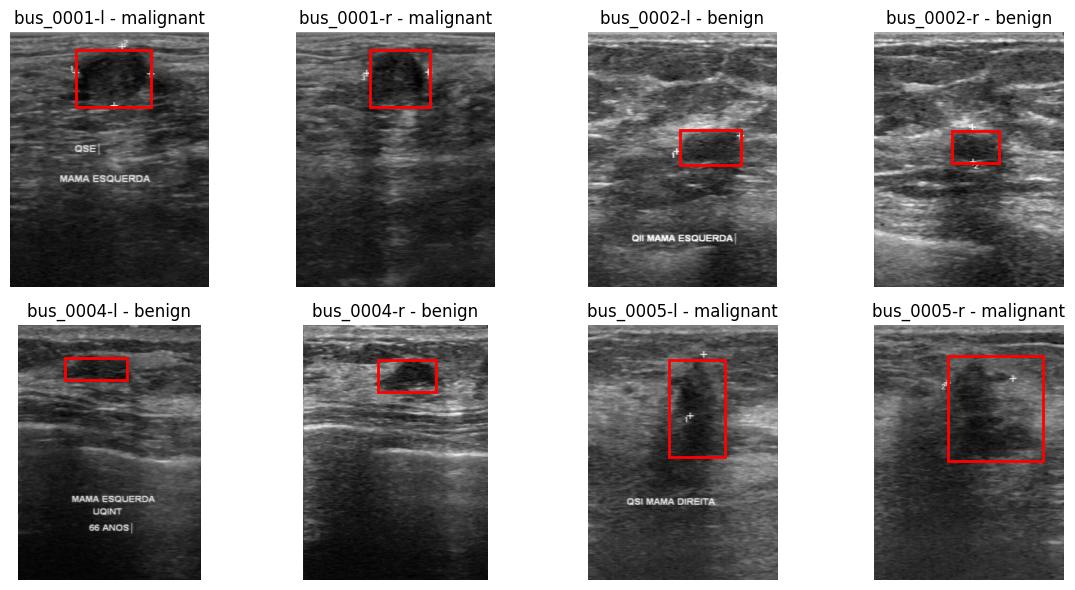

In [ ]:
# I quickly check a few images before training.
show_df = train_df.groupby("Pathology").head(4)
_, axes = plt.subplots(2, 4, figsize=(12, 6))

for ax, row in zip(axes.ravel(), show_df.itertuples(index=False)):
    image= Image.open(images_dir / f"{row.ID}.png").convert("L")
    x, y, w, h = row.BBOX
    ax.imshow(image, cmap='gray')
    ax.add_patch(Rectangle((x, y), w, h, fill=False, edgecolor="red", linewidth=2))
    ax.set_title(f"{row.ID} - {row.Pathology}")
    ax.axis("off")
plt.tight_layout()
# Source: https://matplotlib.org/stable/api/_as_gen/matplotlib.patches.Rectangle.html

<center><font size="5">Preprocessing and Augmentation</font></center>


In [10]:
# I cache cropped images once so training is faster.
def preload(frame, side):
# Creating empty ram storage for all images and label.
    out = np.empty((len(frame), side, side, 3), dtype=np.uint8)
    labels = np.empty(len(frame), dtype=np.float32)

    for i, row in enumerate(frame.itertuples(index=False)):
        img = Image.open(images_dir / f"{row.ID}.png").convert("L")
        x, y, w, h = row.BBOX

        pad_x = round(w * 0.15)
        pad_y = round(h * 0.15)

        crop = img.crop((max(0, x - pad_x),max(0, y - pad_y),
                        min(img.width, x + w + pad_x),min(img.height, y + h + pad_y))).convert("RGB")

        out[i]= np.array(crop.resize((side, side), Image.BILINEAR))
        labels[i] = row.label

    return torch.from_numpy(out), torch.from_numpy(labels)
# For debugging, I used QWEN

In [12]:
# I can give space for random crop movement.
cropped_img = 232
train_imgs, train_y = preload(train_df, cropped_img)
val_imgs, val_y = preload(val_df, cropped_img)
test_imgs, test_y = preload(test_df, cropped_img)
print(train_imgs.shape, val_imgs.shape, test_imgs.shape)

torch.Size([990, 232, 232, 3]) torch.Size([509, 232, 232, 3]) torch.Size([376, 232, 232, 3])


In [15]:
# I  gonna use this so DataLoader can apply transforms to cached tensors.
class CachedDataset(torch.utils.data.Dataset):
    def __init__(self, imgs, labels, transform):
        self.imgs = imgs
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, i):
        img = self.imgs[i].permute(2, 0, 1)
        return self.transform(img), self.labels[i]

In [16]:
# in this cell, I am gonna add small changes so the cnn  should not memorize exact images.
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std =[0.229, 0.224, 0.225]

train_aug_cnn = v2.Compose([v2.RandomCrop(224), v2.RandomHorizontalFlip(),
                            v2.RandomRotation(10),v2.ToDtype(torch.float32, scale=True)])

eval_aug_cnn= v2.Compose([v2.CenterCrop(224),v2.ToDtype(torch.float32, scale=True)])

train_aug_mobile = v2.Compose([v2.RandomCrop(224), v2.RandomHorizontalFlip(),
                               v2.RandomRotation(10), v2.ToDtype(torch.float32,scale=True),
                               v2.Normalize(mean=imagenet_mean, std=imagenet_std)])

eval_aug_mobile = v2.Compose([v2.CenterCrop(224),v2.ToDtype(torch.float32, scale=True),v2.Normalize(mean=imagenet_mean, std=imagenet_std)])

# Source: https://pytorch.org/vision/stable/transforms.html
# https://stackoverflow.com/questions/58151507/why-pytorch-officially-use-mean-0-485-0-456-0-406-and-std-0-229-0-224-0-2

In [17]:
batch_size = 32
pin_memory = device == "cuda"
num_workers = 0

cnn_train_ds = CachedDataset(train_imgs, train_y, train_aug_cnn)
cnn_val_ds = CachedDataset(val_imgs, val_y, eval_aug_cnn)
cnn_test_ds = CachedDataset(test_imgs, test_y, eval_aug_cnn)

mobile_train_ds = CachedDataset(train_imgs, train_y, train_aug_mobile)
mobile_val_ds = CachedDataset(val_imgs, val_y, eval_aug_mobile)
mobile_test_ds = CachedDataset(test_imgs, test_y, eval_aug_mobile)

cnn_train_loader = DataLoader(cnn_train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=pin_memory)
cnn_val_loader = DataLoader(cnn_val_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin_memory)
cnn_test_loader = DataLoader(cnn_test_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin_memory)

mobile_train_loader = DataLoader(mobile_train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=pin_memory)
mobile_val_loader = DataLoader(mobile_val_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin_memory)
mobile_test_loader = DataLoader(mobile_test_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin_memory)

In [26]:
# I weight malignant higher because it is the smaller class.
n_benign_train = int((train_df['label'] == 0).sum())
n_malignant_train =int((train_df['label']== 1).sum())

pos_weight= torch.tensor([n_benign_train / n_malignant_train], device=device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

print("pos_weight", round(pos_weight.item(), 4))
# Source: https://docs.pytorch.org/docs/stable/generated/torch.nn.BCEWithLogitsLoss.html

pos_weight 2.1329


<center><font size="5">Models and Training</font></center>


In [27]:
# I train one epoch and return the average loss.
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y =y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x).squeeze(1)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(y)

    return total_loss / len(loader.dataset)

In [28]:
# I predict probabilities for val and test.
def predict_probs(model, loader, criterion):
    model.eval()
    total_loss = 0
    ys= []
    probs = []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            y =y.to(device, non_blocking=True)

            logits = model(x).squeeze(1)
            total_loss += criterion(logits, y).item()*len(y)

            ys.extend(y.cpu().numpy())
            probs.extend(torch.sigmoid(logits).cpu().numpy())
    return np.array(ys).astype(int), np.array(probs), total_loss/len(loader.dataset)

In [44]:
# I keep the best validation auc weights.
def fit_model(model, train_loader, val_loader, criterion, optimizer, max_epochs, patience, name):
    best_auc = -1
    best_state = None
    stale_epochs = 0
    rows = []

    for epoch in range(1, max_epochs + 1):
        start = time.perf_counter()

        train_loss = train_one_epoch(model, train_loader, criterion, optimizer)
        y_val, val_probs, val_loss = predict_probs(model, val_loader, criterion)
        val_auc = roc_auc_score(y_val, val_probs)
        seconds = time.perf_counter() - start

        rows.append({'epoch':epoch,"train_loss":train_loss,"val_loss": val_loss,"val_auc":val_auc,"seconds":seconds,})
        print(f"{name} epoch {epoch}: train_loss={train_loss:.3f}, val_loss={val_loss:.3f}, val_auc={val_auc:.3f}, seconds={seconds:.1f}")

        if val_auc > best_auc:
            best_auc= val_auc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            stale_epochs=0
        else:
            stale_epochs +=1

        if stale_epochs >=patience:
            print(f"{name} stopped after {epoch} epochs; best val_auc={best_auc:.4f}")
            break

    model.load_state_dict(best_state)
    return pd.DataFrame(rows)
# Source: https://docs.pytorch.org/tutorials/beginner/basics/optimization_tutorial.html

In [ ]:
# I  am gonna build  simple CNN from scratch with four conv blocks
cnn = nn.Sequential(nn.Conv2d(3, 32,3,padding=1), nn.BatchNorm2d(32),nn.ReLU(), nn.MaxPool2d(2),
                    nn.Conv2d(32, 64, 3, padding=1),nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
                    nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),nn.MaxPool2d(2),
                    nn.Conv2d(128,128, 3, padding=1),nn.BatchNorm2d(128), nn.ReLU(),nn.MaxPool2d(2),
                    nn.AdaptiveAvgPool2d(1),
                    nn.Flatten(),
                    nn.Linear(128, 64),nn.ReLU(),nn.Dropout(0.4),
                    nn.Linear(64, 1)).to(device)

cnn_optimizer = torch.optim.Adam(cnn.parameters(), lr=0.0005)
cnn_history= fit_model(cnn, cnn_train_loader, cnn_val_loader, criterion, cnn_optimizer, max_epochs=40, patience=8, name='CNN')
# the model learned fast and validation loss is also fairly low

CNN epoch 1: train_loss=0.877, val_loss=1.175, val_auc=0.579, seconds=2.6
CNN epoch 2: train_loss=0.780, val_loss=0.793, val_auc=0.782, seconds=2.3
CNN epoch 3: train_loss=0.731, val_loss=0.948, val_auc=0.797, seconds=2.2
CNN epoch 4: train_loss=0.723, val_loss=0.781, val_auc=0.818, seconds=2.2
CNN epoch 5: train_loss=0.715, val_loss=1.047, val_auc=0.784, seconds=2.2
CNN epoch 6: train_loss=0.704, val_loss=0.728, val_auc=0.823, seconds=2.1
CNN epoch 7: train_loss=0.700, val_loss=0.879, val_auc=0.819, seconds=2.2
CNN epoch 8: train_loss=0.718, val_loss=0.745, val_auc=0.809, seconds=2.2
CNN epoch 9: train_loss=0.715, val_loss=0.765, val_auc=0.827, seconds=2.2
CNN epoch 10: train_loss=0.696, val_loss=0.867, val_auc=0.832, seconds=2.2
CNN epoch 11: train_loss=0.689, val_loss=0.684, val_auc=0.838, seconds=2.2
CNN epoch 12: train_loss=0.705, val_loss=0.694, val_auc=0.840, seconds=2.3
CNN epoch 13: train_loss=0.666, val_loss=1.236, val_auc=0.783, seconds=2.2
CNN epoch 14: train_loss=0.677, va

In [46]:
# I first train only a new MobileNetV2 classifier head.
weights = MobileNet_V2_Weights.IMAGENET1K_V2
mobile = mobilenet_v2(weights=weights)

for parameter in mobile.features.parameters():
    parameter.requires_grad = False

mobile.classifier = nn.Sequential(nn.Dropout(0.3),nn.Linear(mobile.last_channel, 1),).to(device)

mobile = mobile.to(device)
mobile_optimizer = torch.optim.Adam(filter(lambda parameter: parameter.requires_grad, mobile.parameters()), lr=0.0001)
frozen_history = fit_model(mobile,mobile_train_loader, mobile_val_loader, criterion, mobile_optimizer, max_epochs=30, patience=5, name="MobileNetV2-frozen")
frozen_history["stage"] = 'frozen'

# Source: https://pytorch.org/vision/stable/models/generated/torchvision.models.mobilenet_v2.html

MobileNetV2-frozen epoch 1: train_loss=0.939, val_loss=0.954, val_auc=0.562, seconds=2.6
MobileNetV2-frozen epoch 2: train_loss=0.917, val_loss=0.937, val_auc=0.648, seconds=2.6
MobileNetV2-frozen epoch 3: train_loss=0.891, val_loss=0.914, val_auc=0.711, seconds=2.4
MobileNetV2-frozen epoch 4: train_loss=0.879, val_loss=0.901, val_auc=0.741, seconds=3.1
MobileNetV2-frozen epoch 5: train_loss=0.859, val_loss=0.886, val_auc=0.757, seconds=2.4
MobileNetV2-frozen epoch 6: train_loss=0.844, val_loss=0.877, val_auc=0.758, seconds=2.6
MobileNetV2-frozen epoch 7: train_loss=0.825, val_loss=0.863, val_auc=0.773, seconds=2.5
MobileNetV2-frozen epoch 8: train_loss=0.814, val_loss=0.858, val_auc=0.774, seconds=2.5
MobileNetV2-frozen epoch 9: train_loss=0.801, val_loss=0.852, val_auc=0.778, seconds=2.5
MobileNetV2-frozen epoch 10: train_loss=0.798, val_loss=0.840, val_auc=0.781, seconds=2.5
MobileNetV2-frozen epoch 11: train_loss=0.778, val_loss=0.836, val_auc=0.784, seconds=2.4
MobileNetV2-frozen 

In [ ]:
# I keep the frozen weights in case fine tuning is worse.
best_frozen_auc = float(frozen_history["val_auc"].max())
frozen_best_state = {k: v.detach().cpu().clone() for k, v in mobile.state_dict().items()}

# I fine tune only the last part with a smaller learning rate.
unfreeze_last = 30
for parameter in list(mobile.features.parameters())[-unfreeze_last:]:
    parameter.requires_grad = True

mobile_ft_optimizer = torch.optim.Adam(filter(lambda parameter: parameter.requires_grad, mobile.parameters()), lr=0.00001)
fine_history = fit_model(mobile, mobile_train_loader, mobile_val_loader, criterion, mobile_ft_optimizer, max_epochs=15,patience=5, name="MobileNetV2-finetune")
fine_history['stage']= "fine_tune"

best_finetune_auc = float(fine_history["val_auc"].max())

if best_frozen_auc >best_finetune_auc:
    mobile.load_state_dict(frozen_best_state)
    kept = 'frozen'
else:
    kept= 'fine_tune'
print(f"frozen best {best_frozen_auc:.3f}, fine tune best {best_finetune_auc:.3f}, kept = {kept}")
mobile_history = pd.concat([frozen_history, fine_history], ignore_index=True)
# Source: https://docs.pytorch.org/tutorials/beginner/transfer_learning_tutorial.html
# For debugging, I used QWEN


MobileNetV2-finetune epoch 1: train_loss=0.711, val_loss=0.757, val_auc=0.811, seconds=2.5
MobileNetV2-finetune epoch 2: train_loss=0.705, val_loss=0.758, val_auc=0.811, seconds=2.5
MobileNetV2-finetune epoch 3: train_loss=0.677, val_loss=0.752, val_auc=0.812, seconds=2.5
MobileNetV2-finetune epoch 4: train_loss=0.680, val_loss=0.746, val_auc=0.815, seconds=2.6
MobileNetV2-finetune epoch 5: train_loss=0.691, val_loss=0.738, val_auc=0.819, seconds=2.7
MobileNetV2-finetune epoch 6: train_loss=0.681, val_loss=0.735, val_auc=0.819, seconds=2.5
MobileNetV2-finetune epoch 7: train_loss=0.676, val_loss=0.730, val_auc=0.820, seconds=2.8
MobileNetV2-finetune epoch 8: train_loss=0.677, val_loss=0.724, val_auc=0.825, seconds=2.4
MobileNetV2-finetune epoch 9: train_loss=0.656, val_loss=0.720, val_auc=0.826, seconds=2.4
MobileNetV2-finetune epoch 10: train_loss=0.649, val_loss=0.717, val_auc=0.828, seconds=2.5
MobileNetV2-finetune epoch 11: train_loss=0.655, val_loss=0.719, val_auc=0.827, seconds=2

In [ ]:
# Actually, this is a bit surprising to me, the Mobilenetv2 model is powerful model with millions of parameters, but my small built from scratch 
# did better job. I think this is because pretrained model was not  trained on ultrasound images

<center><font size="5">Evaluation</font></center>


In [34]:
# I choose the threshold on validation. not on test.
def threshold_sweep(y_true, probs):
    rows = []
    for threshold in np.arange(0.05, 0.96, 0.05):
        pred =(probs >= threshold).astype(int)
        rows.append({"threshold":round(float(threshold), 2),"balanced_acc":balanced_accuracy_score(y_true, pred)})
    return pd.DataFrame(rows)

In [52]:
# I draw the matrix so mistakes are easy to see.
def show_confusion(name, cm):
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(cm, cmap="Blues")

    ax.set_xticks([0, 1], labels=['benign', "malignant"])
    ax.set_yticks([0, 1], labels=['benign', "malignant"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(name)

    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center", color="black")

    plt.tight_layout()

In [53]:
# I use the same evaluation path for both models.
def evaluate_model(name, model, val_loader, test_loader, criterion):
    y_val, val_probs, _ = predict_probs(model, val_loader, criterion)
    sweep = threshold_sweep(y_val, val_probs)

    best_idx = int(sweep["balanced_acc"].idxmax())
    threshold = float(sweep.loc[best_idx, "threshold"])

    print(f"{name} validation threshold sweep:")
    print(sweep.to_string(index=False))
    print(f"{name} chosen threshold from val row {best_idx}: {threshold:.2f}")

    y_test, test_probs, _ = predict_probs(model, test_loader, criterion)
    y_pred = (test_probs >= threshold).astype(int)

    test_auc = roc_auc_score(y_test, test_probs)
    test_acc = accuracy_score(y_test, y_pred)
    test_bal_acc = balanced_accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

    print(f"{name} test metrics")
    print("accuracy", round(test_acc, 4))
    print("balanced accuracy", round(test_bal_acc, 4))
    print("AUC", round(test_auc, 4))
    print(classification_report(y_test, y_pred, target_names=["benign", "malignant"], zero_division=0))
    print("confusion matrix")
    print(cm)

    show_confusion(name, cm)

    return { "model": name,"accuracy": test_acc,
             "balanced_acc": test_bal_acc,"AUC": test_auc, "benign_recall": cm[0, 0] / cm[0].sum(),
             "malignant_recall": cm[1, 1] / cm[1].sum(),"chosen_threshold": threshold,}, sweep, cm

CNN validation threshold sweep:
 threshold  balanced_acc
      0.05      0.566176
      0.10      0.604377
      0.15      0.624965
      0.20      0.644065
      0.25      0.679360
      0.30      0.694031
      0.35      0.711643
      0.40      0.721920
      0.45      0.736591
      0.50      0.755674
      0.55      0.761521
      0.60      0.759963
      0.65      0.767229
      0.70      0.761225
      0.75      0.784755
      0.80      0.800827
      0.85      0.766568
      0.90      0.702793
      0.95      0.600627
CNN chosen threshold from val row 15: 0.80
CNN test metrics
accuracy 0.8298
balanced accuracy 0.8165
AUC 0.8976
              precision    recall  f1-score   support

      benign       0.89      0.85      0.87       254
   malignant       0.72      0.78      0.75       122

    accuracy                           0.83       376
   macro avg       0.80      0.82      0.81       376
weighted avg       0.83      0.83      0.83       376

confusion matrix
[[217  37]
 

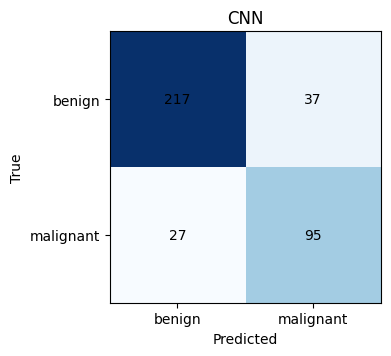

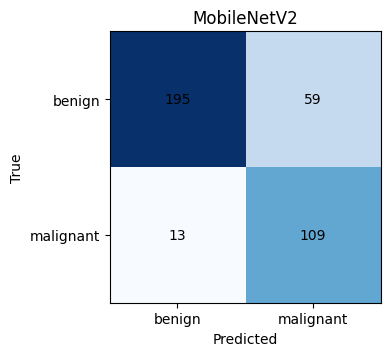

In [54]:
cnn_metrics, cnn_sweep, cnn_cm = evaluate_model("CNN", cnn, cnn_val_loader, cnn_test_loader, criterion)
mobile_metrics, mobile_sweep, mobile_cm = evaluate_model("MobileNetV2", mobile, mobile_val_loader, mobile_test_loader, criterion)

In [56]:
# Comparison of the two models
comparison = pd.DataFrame([cnn_metrics, mobile_metrics]).set_index("model")
comparison

,accuracy,balanced_acc,AUC,benign_recall,malignant_recall,chosen_threshold
model,,,,,,
CNN,0.829787,0.81651,0.897638,0.854331,0.778689,0.8
MobileNetV2,0.808511,0.83058,0.910578,0.767717,0.893443,0.5


In [ ]:
# Honestly,  before training, I expected the pretrained model gets better result. But the fine tuning worked better. 
